# COMP662 — Generative Artificial Intelligence
## Assignment 1: Synthetic Dataset Generation

- #### Task 1:Dataset Understanding and Concise Exploratory Data Analysis
- #### Task 2: Baseline Classifier Construction
- #### Task 3: Generative Model Development and Justification
- #### Task 4: Data Synthesis and Quality Assurance
- #### Task 5: Classification with Synthetic Data and Performance Analysis


### Task 0.1 Imports

In [1]:
# Core libraries: numpy for manual maths, pandas for the small CSVs, torch for the NNs,
# matplotlib for plots. Everything below is commented line by line.
import numpy as np                      # manual backprop + array maths
import pandas as pd                     # read the small CSV datasets
import torch                            # tensors, autograd, layers
import torch.nn as nn                   # neural network building blocks
import matplotlib.pyplot as plt         # 2D and 3D plotting
import seaborn as sns
import joblib
import random
import time
import torch.nn.functional

from sklearn.linear_model import LogisticRegression #Imports for logistic regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score,classification_report
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score



from pathlib import Path



from IPython.display import HTML, display
from IPython.display import Markdown, display

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix



In [2]:
SEED = 42

FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)


def save_figure(name):
    """Write the current figure to figures/ as PDF (slides) and PNG (preview)."""
    plt.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight")
    plt.savefig(FIGURE_DIR / f"{name}.png", dpi=200, bbox_inches="tight")

---
#### 0.5 Checking if CUDA is available
----

In [3]:


# Check if CUDA (GPU) is available
if torch.cuda.is_available():
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected. Using CPU.")

GPU detected: NVIDIA GeForce RTX 4050 Laptop GPU


---

### Task 1: Dataset Understanding and Concise Exploratory Data Analysis.

---

#### Task 1.1: Report class distribution.

In [4]:
# Task 1 Load Dataset

df = pd.read_csv("../data/train.csv")

In [5]:
# Task 1.2 Display first 10 an last 10 rows

display(df.info())
display(df.head(10).style.format("{:.2f}"))
display(df.describe().style.format("{:.2f}"))


# Task 1.3 Show data shape  an NULLs
print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])

print("Number of columns:", df.shape[1])

print("Number of NULLS")
display(df.isnull().sum())



<class 'pandas.DataFrame'>
RangeIndex: 12111 entries, 0 to 12110
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             12111 non-null  int64  
 1   Perimeter        12111 non-null  float64
 2   MajorAxisLength  12111 non-null  float64
 3   MinorAxisLength  12111 non-null  float64
 4   Eccentricity     12111 non-null  float64
 5   ConvexArea       12111 non-null  int64  
 6   Extent           12111 non-null  float64
 7   Solidity         12111 non-null  float64
 8   roundness        12111 non-null  float64
 9   Compactness      12111 non-null  float64
 10  Class            12111 non-null  int64  
dtypes: float64(8), int64(3)
memory usage: 1.0 MB


None

,Area,Perimeter,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Solidity,roundness,Compactness,Class
0,28395.00,610.29,208.18,173.89,0.55,28715.00,0.76,0.99,0.96,0.91,3.00
1,28734.00,638.02,200.52,182.73,0.41,29172.00,0.78,0.98,0.89,0.95,3.00
2,29380.00,624.11,212.83,175.93,0.56,29690.00,0.78,0.99,0.95,0.91,3.00
3,30008.00,645.88,210.56,182.52,0.50,30724.00,0.78,0.98,0.90,0.93,3.00
4,30140.00,620.13,201.85,190.28,0.33,30417.00,0.77,0.99,0.98,0.97,3.00
5,30279.00,634.93,212.56,181.51,0.52,30600.00,0.78,0.99,0.94,0.92,3.00
6,30477.00,670.03,211.05,184.04,0.49,30970.00,0.76,0.98,0.85,0.93,3.00
7,30519.00,629.73,213.00,182.74,0.51,30847.00,0.77,0.99,0.97,0.93,3.00
8,30685.00,635.68,213.53,183.16,0.51,31044.00,0.77,0.99,0.95,0.93,3.00
9,30834.00,631.93,217.23,180.90,0.55,31120.00,0.78,0.99,0.97,0.91,3.00


,Area,Perimeter,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Solidity,roundness,Compactness,Class
count,12111.00,12111.00,12111.00,12111.00,12111.00,12111.00,12111.00,12111.00,12111.00,12111.00,12111.00
mean,52796.42,853.98,319.54,201.97,0.75,53515.05,0.75,0.99,0.87,0.80,1.61
std,28538.96,211.28,84.45,44.05,0.09,28981.66,0.05,0.00,0.06,0.06,1.37
min,20420.00,524.74,183.60,122.51,0.22,20684.00,0.56,0.92,0.49,0.64,0.00
25%,36172.00,702.51,253.31,175.51,0.72,36574.50,0.72,0.99,0.83,0.76,0.00
50%,44573.00,794.46,296.65,192.35,0.76,45117.00,0.76,0.99,0.88,0.80,1.00
75%,61781.00,980.45,376.58,218.09,0.81,62723.50,0.79,0.99,0.92,0.83,3.00
max,248424.00,1884.56,722.49,460.20,0.91,251082.00,0.86,0.99,0.99,0.99,4.00


Dataset shape: (12111, 11)
Number of rows: 12111
Number of columns: 11
Number of NULLS


Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
Extent             0
Solidity           0
roundness          0
Compactness        0
Class              0
dtype: int64

In [6]:

# Count of each class
class_counts = df['Class'].value_counts().sort_index()

# Percentage of each class
class_percentages = df['Class'].value_counts(normalize=True).sort_index() * 100

# Combine into one table
class_distribution = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_percentages.round(2)
})



display(class_distribution.style.format({"Baseline F1": "{:.2f}", "Augmented F1": "{:.2f}", "Change": "{:+.2f}"}))

,Count,Percentage (%)
Class,,
0,3246,26.800000
1,3174,26.210000
2,2336,19.290000
3,1727,14.260000
4,1628,13.440000


### Task 1.2 Most important features.

- Area
    - Corresponds with 3 other features. Also the physical size of the bean will likely be a fundmental charecteristics. 
- Perimeter
    - The second strongest correlation with class.
- MajorAxisLength
    - Highest correlation with class.
- Roundness
    - Most significant inverse relationship with class.
- Compactness
    - Second most significant inverse relationshiop with class.




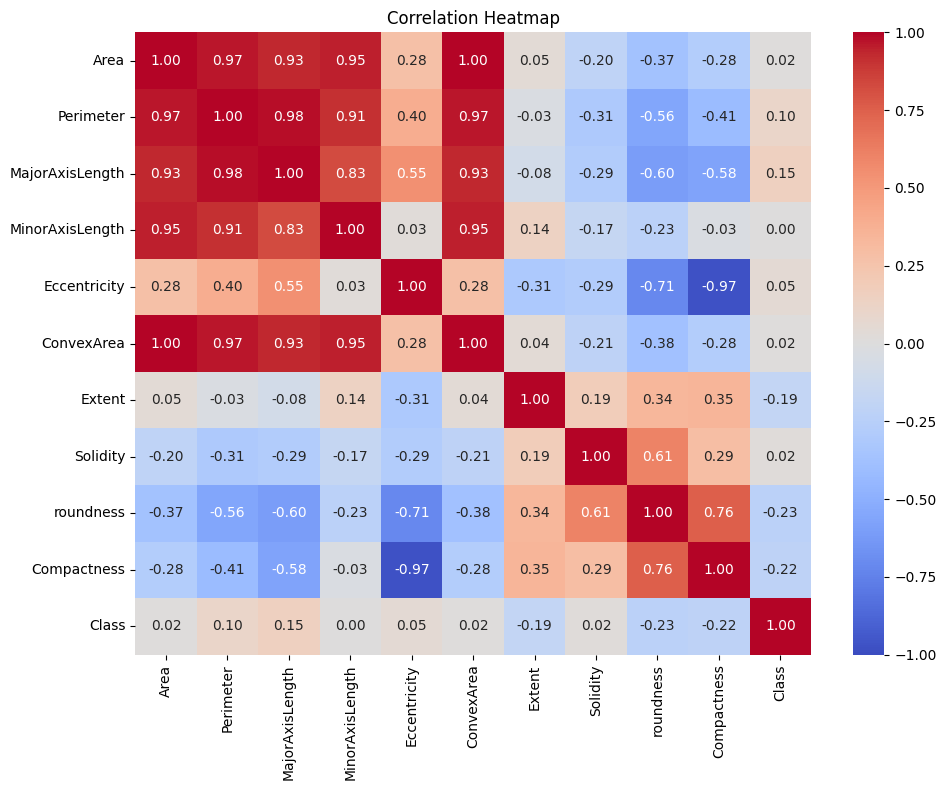

In [7]:
cm = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm, 
    annot=True,          # Show the correlation coefficients inside the squares
    cmap='coolwarm',     # Use a diverging color scheme (blue for negative, red for positive)
    fmt=".2f",           # Round the annotation text to 2 decimal places
    vmin=-1,             # Set minimum value of the color bar to -1
    vmax=1,              # Set maximum value of the color bar to 1
    center=0             # Center the color bar at 0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()



---
Task 1.4 Summarise how the Exploratory Data Analysis:

None of the classes are so overrepresented as to create an imbalance. Resampling may distort original feature distribution.

I plan I using Macro F1 score as I am not planning on resampling, Macro F1 will ensure that minor imbalance does not alter the results.

No datatype conversion will be required as all features are numeric.

I will select Random forest for baseline as it will also not require scalling.

---



---

### Task 2: Baseline Classifier Construtction.

#### Create Traininng and Test (holdover) sets.


A Random Forest classifier was selected as the baseline model as it performs well on tabular datasets, can capture non-linear relationships and classes, and will require minimal preprocessing.

Model development was performed using Stratified 5-fold Cross Validation to preserve class proportions accross folds. In each fold, approximately 80% of the training data was used for learning and 20% was used for validation.

A seperate held-out test set of 20% was reserved for the final evaluation to prevent data leakage. Stratification was used to preserver class distribution.

Macro F1-score was used as the primary evaluation metric because it gives equal importance to every class regardless of frequency, while accuracy was reported as a supporting metric.

Full Dataset <br>
│ <br>
├── Training Set (80%) <br>
│   └── Stratified 5-Fold Cross Validation<br>
│       ├── Fold 1<br>
│       ├── Fold 2<br>
│       ├── Fold 3<br>
│       ├── Fold 4<br>
│       └── Fold 5<br>
│<br>
└── Held-Out Test Set (20%)<br>
    └── Final Evaluation Only<br>

---


In [8]:
X = df.drop("Class", axis=1)
y = df["Class"]

# Hold-out test set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 9688
Test samples: 2423


In [9]:
# Create Random forest classifer

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_macro"
)

print("Fold Scores:", cv_scores)
print("Mean Macro F1:", cv_scores.mean())
cv_macro = cv_scores.mean()

Fold Scores: [0.9299449  0.93319656 0.92196891 0.92980008 0.92937665]
Mean Macro F1: 0.9288574189361345


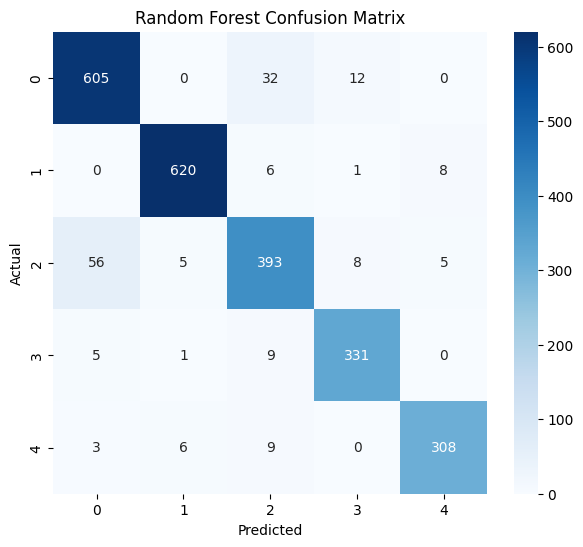

Accuracy: 0.9314898885678911
Macro F1: 0.9310673412611594

Classification Report
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       649
           1       0.98      0.98      0.98       635
           2       0.88      0.84      0.86       467
           3       0.94      0.96      0.95       346
           4       0.96      0.94      0.95       326

    accuracy                           0.93      2423
   macro avg       0.93      0.93      0.93      2423
weighted avg       0.93      0.93      0.93      2423




### Task 2 Results discussion

With fairly high results for Accuracy: **0.9315**  and Macro F1: **0.9311** and the Cross Validation Mean Macro F1 **0.9289** the clossness  of both of the Macro F1 show the Random Forest is generalising well and not overfiting


In [10]:
rf.fit(X_train, y_train)



y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')



cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Accuracy:", accuracy)
print("Macro F1:", macro_f1)

print("\nClassification Report")
print(classification_report(y_test, y_pred))



display(Markdown(f"""
### Task 2 Results discussion

With fairly high results for Accuracy: **{accuracy:0.4}**  and Macro F1: **{macro_f1:0.4}** and the Cross Validation Mean Macro F1 **{cv_macro:0.4}** the clossness  of both of the Macro F1 show the Random Forest is generalising well and not overfiting
"""))

---

### Task 3: Generative Model Development and Justification.

#### Task 3.1 State and justify model.

---
For this task I have chosen CVAE:

I chose a Conditional Variational Autoencoder (CVAE) for the generative model, the objective of the model is to learn the underlying distribution of the beans and thier morphology and generate realistic synthetic observations that can be used to augment the orignal data set. As the data is entirely of numerical tabular features with a catergorical class the CVAE will generate new results by sampling from the latent space. The Conditional componet enables the model to generates smamples based on specific bean classes. The probabilistic nature of CVAEs will provides a clear framework for developing diversere synthetic observations and preserve relationships present in the original data.

Compared to a Generative Adversarial Network (GAN) the CVAE will be more stable in training and less prone to issues such as mode collapse. If the project required the production of images the choice may have been different.

---

#### Task 3.2  Describe CVAE architecture:

The CVAE consists of three main compents;

1. Encoder:<br>
    - Encoder recives the input feature vector with the label. <br>
        - Bean Features + Class Label.<br>
    - It will then output two values a mean (μ) and a standard deviation (σ).<br>        
1. Latent Space: A variation encoder learns a probabilistic distribution, A latent vector is sampled using the reparameterisation trick:<br>
    - z = μ + σ × ε where ε ~ N(0,1). <br>
1. Decoder: <br>
    - The decoder recieves the Latent Vector and the Class lable and recreates the original feature values.<br>

---
#### Task 3.3

 During training, the CVAE compresses bean measurements into a low-dimensional latent space. Both the encoder and decoder are conditioned on class labels via one-hot vectors, allowing the decoder to reconstruct feature values while capturing class-specific distributions.

---
#### Task 3.4 Data Preprocessing:

There are three preprocessing steps that will be required by the CVAE:

1. Training/Test Split: <br>
    - The dataset will be divided into training and test sets using stratified sampling. Only the training set will be used to train the CVAE, leaving the test set untocuhed to prevent data leakage.<br>
1. Feature Scaling:<br>
    - The bean features exist on very different numerical scales, for example:<br>
        - Area and ConvexArea are measured in tens of thousands.<br>
        - Solidity and roundness have values between approximately 0 and 1.<br>
1. Class Encoding:
    - The target varible (Class) will be converted by one-hot encoding before being supplied to the CVAE.

---

#### Task 3.5 Assumptions, Limitations and Risks:

The CVAE model makes several assumptions:

- The training dataset is representative of the true population of bean varieties.
- The latent space can effectively capture the underlying structure of the bean morphology measurements.
- Similar observations occupy nearby regions in latent space.
- New samples generated from latent space will follow distributions similar to those observed in the original training data.


Limitations and Risks:

- Over-smoothing
    - VAEs can produce smoother distributions than the real data, this may reult in generated samples may have reduced variability comparded to the original dataset.

- Reconstruction Error:
    - The decoder reconstructs based on approximations, this can reduce the reproduction of complex feature relationships.

- Synthetic Data Utility: 
    - If the synthetic data is too close statiscally to the training data it may not improve performance.

- Potential Overfitting :
    - The model may match the training data to much and result in overfitting.

---




---

### Task 4: Data Synthesis and Quality Assurance.
---
Task 4.1 Describe the training process of the generative model.<br>
1. Prepare Data.<br>
1. Define CVAE.<br>
1. Loss Function.<br>
1. Train Function.<br>

Task 4.2 Explain and justify your data generation strategy

Task 4.3 Generate a synthetic dataset

Task 4.4 Compare the real and synthetic datasets 

Task 4.5: Critically evaluate the quality of the generated data


---

---

#### Task 4.1.1 : Prepare Data

1. Split the data train and test 80/20.
1. Scale training feature.
1. One-Hot Encode
---

In [11]:
# Split Data
X = df.drop("Class", axis=1)
y = df["Class"]

# Hold-out test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Scale training features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

num_features = X_train.shape[1]
num_classes = y.nunique()


X_tensor = torch.FloatTensor(X_train_scaled)

# One-hot encode class labels


y_tensor = torch.nn.functional.one_hot(
    torch.LongTensor(y_train.values),
    num_classes=num_classes
).float()
dataset = TensorDataset(X_tensor, y_tensor)

loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

C:\Users\NedMatheson\AppData\Local\Temp\ipykernel_16316\3176788736.py:28: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  torch.LongTensor(y_train.values),


---

#### 4.1.2 : Define CVAE

---

In [12]:
# Define CVAE

latent_dim = 10


class CVAE(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(num_features + num_classes, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        self.mu = nn.Linear(32, latent_dim)
        self.logvar = nn.Linear(32, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, num_features)
        )

    def encode(self, x, c):

        h = self.encoder(torch.cat([x, c], dim=1))
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z, c):

        return self.decoder(torch.cat([z, c], dim=1))

    def forward(self, x, c):

        mu, logvar = self.encode(x, c)

        z = self.reparameterize(mu, logvar)

        reconstructed = self.decode(z, c)

        return reconstructed, mu, logvar

---
#### Task 4.1.4 Loss Function

----

In [13]:
# Loss Function
def loss_function(recon_x, x, mu, logvar):

    recon_loss = nn.MSELoss(reduction='sum')(
        recon_x,
        x
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return recon_loss + kl_loss

---

#### Task 4.1.5 Train Function

---

In [14]:
#Train CVAE
model = CVAE()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 100

for epoch in range(epochs):

    total_loss = 0

    for batch_x, batch_c in loader:

        optimizer.zero_grad()

        recon, mu, logvar = model(
            batch_x,
            batch_c
        )

        loss = loss_function(
            recon,
            batch_x,
            mu,
            logvar
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch}, Loss {total_loss:.2f}"
        )


Epoch 0, Loss 81795.62
Epoch 10, Loss 27509.75
Epoch 20, Loss 25465.84
Epoch 30, Loss 24718.51
Epoch 40, Loss 24422.46
Epoch 50, Loss 24189.66
Epoch 60, Loss 24056.73
Epoch 70, Loss 23896.04
Epoch 80, Loss 23927.84
Epoch 90, Loss 23797.88


---
### Task 4.2 Explain and justify your data generation strategy

The objective of the synthetic data generation is to create realistic bean observation that can later be used to augment the original training dataset.

A conditional generation strategy was adopted where samples were generated seperatly for each bean class. 

2000 samples will be created for each class, resulting in 10,000 synthetic observations.

This strategy was chosen because:

All classes receive equal representation in the synthetic dataset.
Class-specific morphological patterns can be preserved.
The synthetic dataset is sufficiently large to evaluate augmentation effects during Task 5.

---

---
#### Task 4.3: Generate Synthetic Samples

---

In [15]:
# Generate SyntheticSamples
model.eval()

n_samples = 1000

target_class = 3

z = torch.randn(
    n_samples,
    latent_dim
)

class_vector = torch.nn.functional.one_hot(
    torch.full((n_samples,),
               target_class),
    num_classes=num_classes
).float()

with torch.no_grad():

    synthetic_scaled = model.decode(
        z,
        class_vector
    )

synthetic_scaled = synthetic_scaled.numpy()

# Back to original scale
synthetic_data = scaler.inverse_transform(
    synthetic_scaled
)

synthetic_df = pd.DataFrame(
    synthetic_data,
    columns=X.columns
)

synthetic_df["Class"] = target_class

---

####  Generate all classes

---

In [16]:
# Generate All Classes
synthetic_frames = []

for cls in range(5):

    n = 2000

    z = torch.randn(n, latent_dim)

    labels = torch.nn.functional.one_hot(
        torch.full((n,), cls),
        num_classes=5
    ).float()

    with torch.no_grad():

        samples = model.decode(
            z,
            labels
        ).numpy()

    samples = scaler.inverse_transform(samples)

    temp = pd.DataFrame(
        samples,
        columns=X.columns
    )

    temp["Class"] = cls

    synthetic_frames.append(temp)

synthetic_dataset = pd.concat(
    synthetic_frames,
    ignore_index=True
)

In [17]:
print("Synthetic Dataset Shape:", synthetic_dataset.shape)
synthetic_dataset.info()
synthetic_dataset.describe().round(2)

# X_train.describe().round(2)

Synthetic Dataset Shape: (10000, 11)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             10000 non-null  float32
 1   Perimeter        10000 non-null  float32
 2   MajorAxisLength  10000 non-null  float32
 3   MinorAxisLength  10000 non-null  float32
 4   Eccentricity     10000 non-null  float32
 5   ConvexArea       10000 non-null  float32
 6   Extent           10000 non-null  float32
 7   Solidity         10000 non-null  float32
 8   roundness        10000 non-null  float32
 9   Compactness      10000 non-null  float32
 10  Class            10000 non-null  int64  
dtypes: float32(10), int64(1)
memory usage: 468.9 KB


,Area,Perimeter,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Solidity,roundness,Compactness,Class
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,50963.45,847.31,317.83,199.38,0.75,51609.44,0.75,0.99,0.87,0.80,2.00
std,21337.73,170.74,72.33,32.74,0.10,21686.59,0.04,0.00,0.06,0.07,1.41
min,30692.75,650.93,220.67,158.67,0.40,30602.96,0.57,0.96,0.69,0.66,0.00
25%,38069.86,709.78,250.37,183.43,0.72,38492.46,0.73,0.99,0.81,0.76,1.00
50%,45536.23,802.54,301.51,191.93,0.76,45950.78,0.76,0.99,0.88,0.80,2.00
75%,55327.69,936.54,375.87,202.56,0.81,56096.42,0.77,0.99,0.91,0.83,3.00
max,321197.91,2345.19,867.36,563.08,0.91,326549.38,0.84,0.99,0.96,0.97,4.00


### Task 4.4 : Compare the real and synthetic datasets 



In [18]:
# Real dataset distribution
real_counts = y_train.value_counts().sort_index()

real_percentages = (
    y_train.value_counts(normalize=True)
    .sort_index() * 100
)

# Synthetic dataset distribution
synthetic_counts = (
    synthetic_dataset["Class"].value_counts()
    .sort_index()
)

synthetic_percentages = (
    synthetic_dataset["Class"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

# Combine into a single comparison table
class_comparison = pd.DataFrame({
    "Real Count": real_counts,
    "Real %": real_percentages.round(2),
    "Synthetic Count": synthetic_counts,
    "Synthetic %": synthetic_percentages.round(2)
})

display(class_comparison.describe().style.format("{:.2f}"))

,Real Count,Real %,Synthetic Count,Synthetic %
count,5.00,5.00,5.00,5.00
mean,1937.60,20.00,2000.00,20.00
std,615.42,6.35,0.00,0.00
min,1302.00,13.44,2000.00,20.00
25%,1381.00,14.25,2000.00,20.00
50%,1869.00,19.29,2000.00,20.00
75%,2539.00,26.21,2000.00,20.00
max,2597.00,26.81,2000.00,20.00


In [19]:
real_stats = X_train.describe().T

synthetic_stats = (
    synthetic_dataset
    .drop("Class", axis=1)
    .describe()
    .T
)

comparison_stats = pd.DataFrame({
    "Real Mean": real_stats["mean"],
    "Synthetic Mean": synthetic_stats["mean"],
    "Real Std": real_stats["std"],
    "Synthetic Std": synthetic_stats["std"]
})

display(comparison_stats.describe().style.format("{:.2f}"))

,Real Mean,Synthetic Mean,Real Std,Synthetic Std
count,10.00,10.00,10.00,10.00
mean,10751.95,10394.16,5751.99,4330.04
std,22305.98,21554.28,12037.54,9056.30
min,0.75,0.75,0.00,0.00
25%,0.82,0.82,0.06,0.06
50%,101.44,100.18,21.95,16.42
75%,719.94,714.94,179.09,146.14
max,53429.61,51609.44,28810.20,21686.59


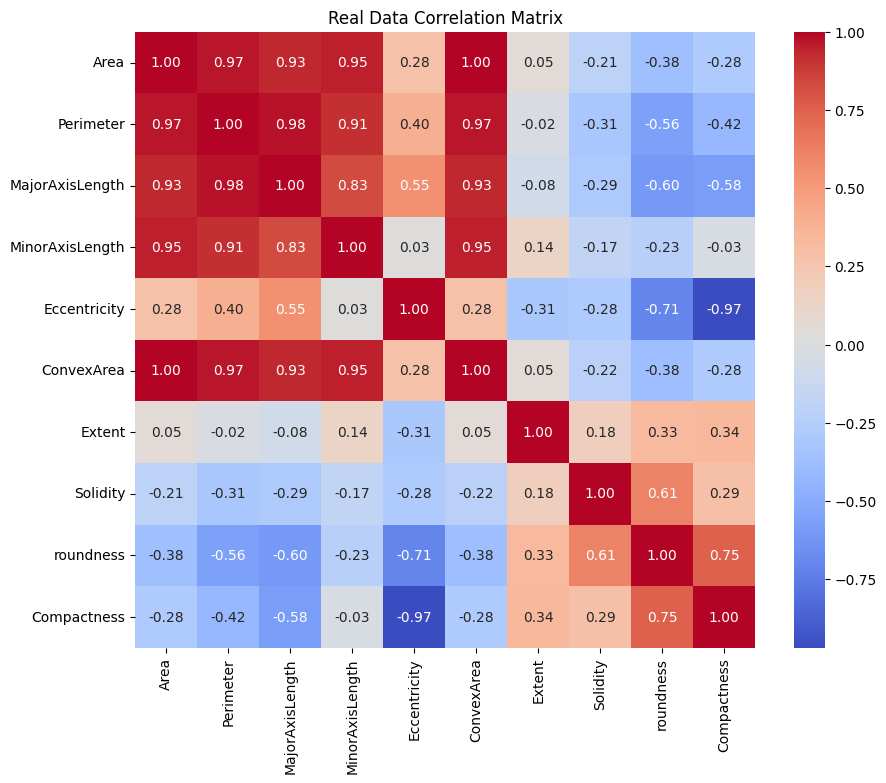

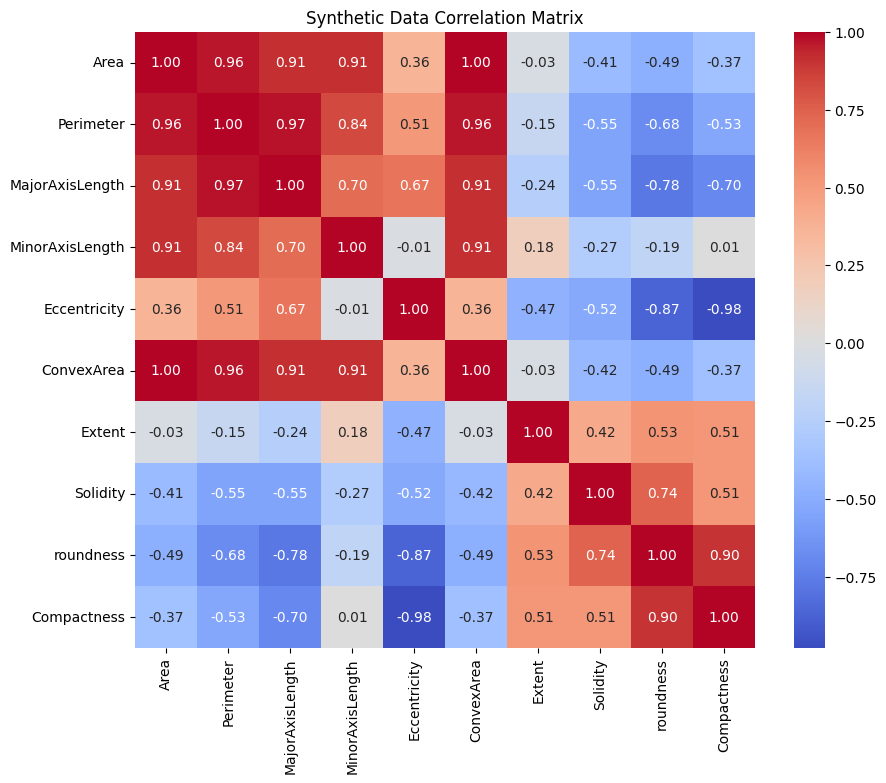

In [20]:
real_corr = X_train.corr()

synthetic_corr = (
    synthetic_dataset
    .drop("Class", axis=1)
    .corr()
)

plt.figure(figsize=(10,8))
sns.heatmap(
    real_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Real Data Correlation Matrix")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(
    synthetic_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Synthetic Data Correlation Matrix")
plt.show()



In [21]:
augmented_train = pd.concat(
    [
        pd.concat([X_train, y_train], axis=1),
        synthetic_dataset
    ],
    ignore_index=True
)

In [22]:
#display(augmented_train.style.format({"Baseline F1": "{:.3f}", "Augmented F1": "{:.3f}", "Change": "{:+.3f}"}))

#display(synthetic_dataset.shape.style.format({"Baseline F1": "{:.3f}", "Augmented F1": "{:.3f}", "Change": "{:+.3f}"}))

In [23]:
# Calculate values directly from the data

synthetic_rows = len(synthetic_dataset)
real_rows = len(X_train)
synthetic_dist = (
    synthetic_dataset["Class"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

real_dist = (
    y_train
    .value_counts(normalize=True)
    .sort_index() * 100
)

area_min = synthetic_dataset["Area"].min()
area_max = synthetic_dataset["Area"].max()

perimeter_min = synthetic_dataset["Perimeter"].min()
perimeter_max = synthetic_dataset["Perimeter"].max()

roundness_min = synthetic_dataset["roundness"].min()
roundness_max = synthetic_dataset["roundness"].max()

compactness_min = synthetic_dataset["Compactness"].min()
compactness_max = synthetic_dataset["Compactness"].max()

real_area_min = X_train["Area"].min()
real_area_max = X_train["Area"].max()

real_perimeter_min = X_train["Perimeter"].min()
real_perimeter_max = X_train["Perimeter"].max()

real_roundness_min = X_train["roundness"].min()
real_roundness_max = X_train["roundness"].max()

real_compactness_min = X_train["Compactness"].min()
real_compactness_max = X_train["Compactness"].max()


### Task 4.5: Critically evaluate the quality of the generated data



display(Markdown(f"""
---
### Task 4.5: Critically evaluate the quality of the generated data
"""
))


display(Markdown(f"""

<div style="font-size:17px">

Visual inspection of the Correlation Matrix are very similar, which shows that the process was at least superfically sucessful.


Looking further at the tables the generated values fall within the similer ranges as the real training data. The synthetic records retain plausabile relationships between size and shape based features.

The CVAE generated **{synthetic_rows:,}** synthetic observations.<br>

The synthetic dataset contained 
**{synthetic_dist[0]:,.0f}%** Class 1, 
**{synthetic_dist[1]:.1f}%** Class 2,
**{synthetic_dist[2]:,.0f}%** Class 3, 
**{synthetic_dist[3]:,.0f}%** Class 4,and 
**{synthetic_dist[4]:,.0f}%** Class 5 observations, the smooth 20% over all five classes was expected, this mean each class has all the bean  varieies equally represented within the synthetic dataset.

In comparison, the original training dataset contained 
**{real_dist[0]:,.0f}%** Class 1,
**{real_dist[1]:,.0f}%** Class 2,
**{real_dist[2]:,.0f}%** Class 3,
**{real_dist[3]:,.0f}%** Class 4, and 
**{real_dist[4]:,.0f}%** Class 4 observations.

This indicates that the synthetic dataset is more balanced than the original training dataset.

The CVAE generated Generated Area values ranged from **{area_min:,.0f}** to **{area_max:,.0f}**, while generated Perimeter values ranged from **{perimeter_min:.2f}** to **{perimeter_max:.2f}**, generated roundness values ranged from approximately
**{roundness_min:.2f}** to **{roundness_max:.2f}**, and Compactness values ranged from approximately **{compactness_min:.2f}** to **{compactness_max:.2f}**.

The original data had area Area values ranged from **{real_area_min:,.0f}** to **{real_area_max:,.0f}**, while real Perimeter values ranged from **{real_perimeter_min:.2f}** to **{real_perimeter_max:.2f}**, generated roundness values ranged from approximately
**{real_roundness_min:.2f}** to **{real_roundness_max:.2f}**, and Compactness values ranged from **{real_compactness_min:.2f}** to **{real_compactness_max:.2f}**.

---
"""))


---
### Task 4.5: Critically evaluate the quality of the generated data




<div style="font-size:17px">

Visual inspection of the Correlation Matrix are very similar, which shows that the process was at least superfically sucessful.


Looking further at the tables the generated values fall within the similer ranges as the real training data. The synthetic records retain plausabile relationships between size and shape based features.

The CVAE generated **10,000** synthetic observations.<br>

The synthetic dataset contained 
**20%** Class 1, 
**20.0%** Class 2,
**20%** Class 3, 
**20%** Class 4,and 
**20%** Class 5 observations, the smooth 20% over all five classes was expected, this mean each class has all the bean  varieies equally represented within the synthetic dataset.

In comparison, the original training dataset contained 
**27%** Class 1,
**26%** Class 2,
**19%** Class 3,
**14%** Class 4, and 
**13%** Class 4 observations.

This indicates that the synthetic dataset is more balanced than the original training dataset.

The CVAE generated Generated Area values ranged from **30,693** to **321,198**, while generated Perimeter values ranged from **650.93** to **2345.19**, generated roundness values ranged from approximately
**0.69** to **0.96**, and Compactness values ranged from approximately **0.66** to **0.97**.

The original data had area Area values ranged from **20,420** to **248,424**, while real Perimeter values ranged from **524.74** to **1884.56**, generated roundness values ranged from approximately
**0.49** to **0.99**, and Compactness values ranged from **0.64** to **0.99**.

---


---

### Task 5: Classification with Synthetic Data and Performance Analysis.

#### Task 5.1 Create the Augmented Training Dataset

#### Task 5.2 Split Augmented Features and Labels

#### Task 5.3 Retrain the Same Random Forest

#### Task 5.4 Evaluate on the Same Test Set

#### Task 5.5 Confusion Matrix

#### Task 5.6 Compare Baseline vs Augmented

#### Task 5.7 Compare Class-Level Performance


---

#### Task 5.1 Create the Augmented Training Dataset

In [24]:
# Original training data
train_df = pd.concat(
    [X_train, y_train],
    axis=1
)

# Augmented training data
augmented_train = pd.concat(
    [train_df, synthetic_dataset],
    ignore_index=True
)

print("Original training shape:", train_df.shape)
print("Synthetic shape:", synthetic_dataset.shape)
print("Augmented shape:", augmented_train.shape)

Original training shape: (9688, 11)
Synthetic shape: (10000, 11)
Augmented shape: (19688, 11)


#### Task 5.2 Split Augmented Features and Labels

In [25]:
X_aug = augmented_train.drop("Class", axis=1)
y_aug = augmented_train["Class"]

#### Task 5.3 Retrain the Same Random Forest


In [26]:
rf_aug = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_aug.fit(X_aug, y_aug)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

#### Task 5.4 Evaluate on the Same Test Set

In [27]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

y_pred_aug = rf_aug.predict(X_test)

aug_accuracy = accuracy_score(
    y_test,
    y_pred_aug
)

aug_macro_f1 = f1_score(
    y_test,
    y_pred_aug,
    average="macro"
)

print("Accuracy:", aug_accuracy)
print("Macro F1:", aug_macro_f1)

print(
    classification_report(
        y_test,
        y_pred_aug
    )
)

Accuracy: 0.9343788691704499
Macro F1: 0.9340793291232533
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       649
           1       0.98      0.98      0.98       635
           2       0.89      0.85      0.87       467
           3       0.94      0.96      0.95       346
           4       0.96      0.95      0.96       326

    accuracy                           0.93      2423
   macro avg       0.94      0.93      0.93      2423
weighted avg       0.93      0.93      0.93      2423



#### Task 5.5 Confusion Matrix

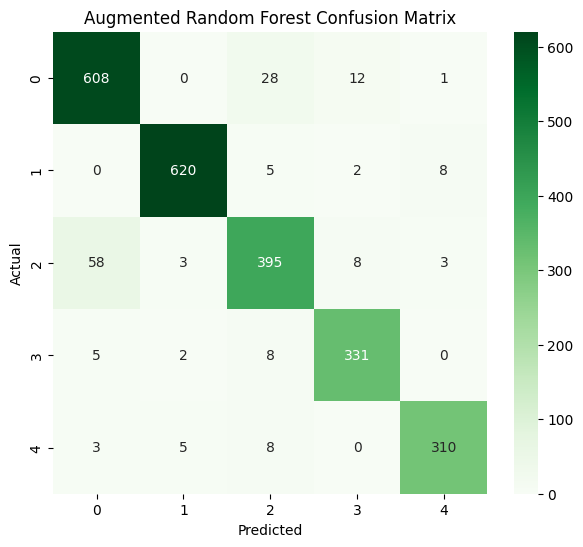

In [28]:
cm_aug = confusion_matrix(
    y_test,
    y_pred_aug
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_aug,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title(
    "Augmented Random Forest Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#### Task 5.6 Compare Baseline vs Augmented

In [29]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline RF",
        "Augmented RF"
    ],
    "Accuracy": [
        accuracy,
        aug_accuracy
    ],
    "Macro F1": [
        macro_f1,
        aug_macro_f1
    ]
})



display(comparison.style.format({"Baseline F1": "{:.3f}", "Augmented F1": "{:.3f}", "Change": "{:+.3f}"}))

,Model,Accuracy,Macro F1
0,Baseline RF,0.931490,0.931067
1,Augmented RF,0.934379,0.934079


#### Task 5.7 Compare Class-Level Performance

In [31]:
baseline_report = pd.DataFrame(
    classification_report(
        y_test,
        y_pred,
        output_dict=True
    )
).transpose()

augmented_report = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_aug,
        output_dict=True
    )
).transpose()

comparison_classes["Change"] = (
    comparison_classes["Augmented F1"]
    - comparison_classes["Baseline F1"]
)

comparison_classes["Change"] = (
    comparison_classes["Change"]
    .map(lambda x: f"{x:+.3f}")
)


comparison_classes = pd.DataFrame({
    "Baseline F1": baseline_report["f1-score"],
    "Augmented F1": augmented_report["f1-score"]
})

comparison_classes["Change"] = (
    comparison_classes["Augmented F1"]
    - comparison_classes["Baseline F1"]
)

display(
    comparison_classes.style.format({
        "Baseline F1": "{:.3f}",
        "Augmented F1": "{:.3f}",
        "Change": "{:+.3f}"
    })
)

,Baseline F1,Augmented F1,Change
0,0.918,0.919,+0.001
1,0.979,0.980,+0.002
2,0.858,0.867,+0.009
3,0.948,0.947,-0.001
4,0.952,0.957,+0.005
accuracy,0.931,0.934,+0.003
macro avg,0.931,0.934,+0.003
weighted avg,0.931,0.934,+0.003


#### Metrics Comparison table and Augmented Confusion Matrix:

,Model,Accuracy,Macro F1
0,Baseline Random Forest,0.931,0.931
1,Augmented Random Forest,0.934,0.934


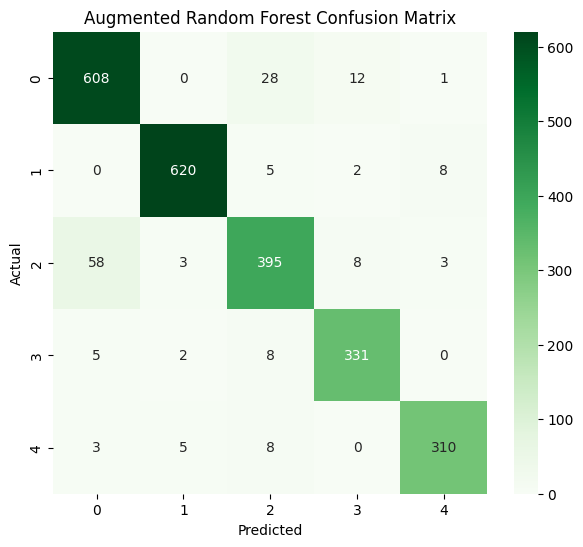

In [34]:
comparison_metrics = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Augmented Random Forest"
    ],
    "Accuracy": [
        accuracy,
        aug_accuracy
    ],
    "Macro F1": [
        macro_f1,
        aug_macro_f1
    ]
})

display(
    comparison_metrics.style.format({
        "Accuracy": "{:.3f}",
        "Macro F1": "{:.3f}"
    })
)
cm_aug = confusion_matrix(
    y_test,
    y_pred_aug
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_aug,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Augmented Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [83]:

display(Markdown("""
---
<div style="font-size:30px">
Task 5 discussion <br>

<div style="font-size:22px">

Performance Comparison
"""))



display(Markdown(f"""

<div style="font-size:17px">


The synthetic dataset generated by the CVAE created another **{synthetic_dataset.shape[0]}** that added to the  **{train_df.shape[0]}** to make a total of **{augmented_train.shape[0]}**. <br>
Random Forest classifier was retrained using the same preproccessing pipeline and hyperparameters as the baseline model. <br>
The Augmented model achieved an Accuracy of **{aug_accuracy:.3f}** compared to ***{accuracy:.3f}** for the baseline model. <br> 
The augmented Macro F1  increased to **{aug_macro_f1:.3f}**  from **{macro_f1:.3f}** <br> 
These results indicate a small but inconsistent improvement in classification perfomance with the synthetic data added.


"""))




display(Markdown("""
---


<div style="font-size:22px">
Class-Level Analysis
"""))
display(Markdown(f"""

<div style="font-size:17px">

he largest improvement was oberserve for class 3, where the f1 score increased from **{baseline_report.loc['2', 'f1-score']:.3f}** to **{augmented_report.loc['2', 'f1-score']:.3f}** an increase of **{augmented_report.loc['2', 'f1-score'] - baseline_report.loc['2', 'f1-score']:.3f}**
<br>class 1 went from **{baseline_report.loc['0', 'f1-score']:.3f}** to **{augmented_report.loc['0', 'f1-score']:.3f}** an increase of **{augmented_report.loc['0', 'f1-score'] - baseline_report.loc['0', 'f1-score']:.3f}**
<br>class 2 went from **{baseline_report.loc['1', 'f1-score']:.3f}** to **{augmented_report.loc['1', 'f1-score']:.3f}** an increase of **{augmented_report.loc['1', 'f1-score'] - baseline_report.loc['1', 'f1-score']:.3f}**
<br>class 4 went from **{baseline_report.loc['3', 'f1-score']:.3f}** to **{augmented_report.loc['3', 'f1-score']:.3f}** an decrease of **{augmented_report.loc['3', 'f1-score'] - baseline_report.loc['3', 'f1-score']:.3f}**
<br>class 5 went from **{baseline_report.loc['4', 'f1-score']:.3f}** to **{augmented_report.loc['4', 'f1-score']:.3f}** an increase of **{augmented_report.loc['4', 'f1-score'] - baseline_report.loc['4', 'f1-score']:.3f}**



"""))



display(Markdown("""
---


<div style="font-size:22px">
Critical Discussion
"""))
display(Markdown(f"""

<div style="font-size:17px">


"""))


display(Markdown(f"""

<div style="font-size:17px">

The synthetic data generated by the CVAE had a positive by modest effect on the classification performance. This suggests that the synthetic data was statistically realistic and contained useful information that complimented the original data.

One explanation for the modest improvement may be that the random forrest already had a strong result with a Macro F1 score of  **{macro_f1:0.4}** limiting the opertunity for perfromance gains.

Overall the synthetic data improved Accuracy and Macro-F1 scores while maintaining performance accross all bean classes. The aumened random forest model provides slightly better performance than the baseline and is selected for the model for submission

"""))


---
<div style="font-size:30px">
Task 5 discussion <br>

<div style="font-size:22px">

Performance Comparison




<div style="font-size:17px">


The synthetic dataset generated by the CVAE created another **10000** that added to the  **9688** to make a total of **19688**. <br>
Random Forest classifier was retrained using the same preproccessing pipeline and hyperparameters as the baseline model. <br>
The Augmented model achieved an Accuracy of **0.934** compared to ***0.931** for the baseline model. <br> 
The augmented Macro F1  increased to **0.934**  from **0.931** <br> 
These results indicate a small but inconsistent improvement in classification perfomance with the synthetic data added.





---


<div style="font-size:22px">
Class-Level Analysis




<div style="font-size:17px">

he largest improvement was oberserve for class 3, where the f1 score increased from **0.858** to **0.867** an increase of **0.009**
<br>class 1 went from **0.918** to **0.919** an increase of **0.001**
<br>class 2 went from **0.979** to **0.980** an increase of **0.002**
<br>class 4 went from **0.948** to **0.947** an decrease of **-0.001**
<br>class 5 went from **0.952** to **0.957** an increase of **0.005**






---


<div style="font-size:22px">
Critical Discussion




<div style="font-size:17px">






<div style="font-size:17px">

The synthetic data generated by the CVAE had a positive by modest effect on the classification performance. This suggests that the synthetic data was statistically realistic and contained useful information that complimented the original data.

One explanation for the modest improvement may be that the random forrest already had a strong result with a Macro F1 score of  **0.9311** limiting the opertunity for perfromance gains.

Overall the synthetic data improved Accuracy and Macro-F1 scores while maintaining performance accross all bean classes. The aumened random forest model provides slightly better performance than the baseline and is selected for the model for submission



In [92]:
joblib.dump(rf_aug,"../models/bean_classifier_rf_augmented.pkl")
joblib.dump(scaler,"../models/bean_scaler.pkl")

['../models/bean_scaler.pkl']

In [89]:
loaded_model = joblib.load(
    "../models/bean_classifier_rf_augmented.pkl"
)

print(type(loaded_model))


<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [90]:
sample_predictions = loaded_model.predict(
    X_test.head()
)

print(sample_predictions)

[0 0 0 1 3]
